<img src="./Imagenes/logo_UTN.svg" align="right" width="150" />

#### Teoría de los Circuitos II

# Trabajo Práctico de Laboratorio N2
#### Alumno: Lucas Gallero
#### Profesor: Mariano Llamedo Soria
#### Ayudante de TPs: David Moharos

**Filtros digitales IIR: Chebyshev pasabajos y notch**

----

# Enunciado

## Plantillas

| Filtro (OPAMP) | Función de aproximación | $f_p$ | $f_s$ | $\alpha_{\max}$ | $\alpha_{\min}$ |
|:--|:--|:--|:--|:--|:--|
| A | Chebyshev | 100 Hz | 300 Hz | 1 dB | 60 dB |

| Filtro (OPAMP) | Tipo | $f_{\mathrm{notch}}$ | BW @ 3 dB |
|:--|:--|:--|:--|
| B | Notch | 50 Hz | 1 Hz |

## Análisis y simulación (*Pre-Lab*)

1. Obtener los coeficientes del filtro digital usando la función `iirdesign`.
2. Simulación de la función transferencia en Python para una frecuencia de muestreo **configurable**.

## Implementación (STM32)

3. Compilar sin errores el proyecto en el IDE.

_____


In [1]:
# Las librerías que utilizaremos se cargan una sola vez.
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import brentq
from IPython.display import display, Markdown, Math, Image

In [2]:
# ============================================================
# Configuración de gráficos y funciones auxiliares
# ============================================================
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

def mostrar_tabla(encabezados, filas):
    """Muestra una tabla Markdown con los resultados calculados."""
    tabla = "| " + " | ".join(encabezados) + " |\n"
    tabla += "| " + " | ".join(["---"] * len(encabezados)) + " |\n"
    for fila in filas:
        tabla += "| " + " | ".join(str(valor) for valor in fila) + " |\n"
    display(Markdown(tabla))

def formato(valor, decimales=2):
    return f"{valor:.{decimales}f}".replace(".", ",")

---

# <ins>Resolución

## <ins>1. Obtención de los coeficientes con Python</ins>

### <ins>1.1 Programa utilizado y frecuencia de muestreo</ins>

Se configuró una frecuencia de muestreo nominal de $1\,\mathrm{kHz}$, tanto en Python como en `filter.h`. El período de muestreo y la frecuencia de Nyquist son

$$T_m=\frac{1}{f_m}=1\,\mathrm{ms},\qquad f_N=\frac{f_m}{2}=500\,\mathrm{Hz}.$$

Si se modifica la frecuencia de muestreo, deben recalcularse los coeficientes y actualizarse la configuración de la placa.

In [3]:
# ============================================================
# Parámetros de diseño
# ============================================================
FS_SAMPLING = 1000.0
A_WP = 100.0
A_WS = 300.0
A_GPASS = 1.0
A_GSTOP = 60.0
B_FNOTCH = 50.0
B_BW3DB = 1.0

print(f"Frecuencia de muestreo: {FS_SAMPLING:g} Hz")
print(f"Período de muestreo: {1000 / FS_SAMPLING:g} ms")
print(f"Frecuencia de Nyquist: {FS_SAMPLING / 2:g} Hz")

Frecuencia de muestreo: 1000 Hz
Período de muestreo: 1 ms
Frecuencia de Nyquist: 500 Hz


## <ins>1.2 Diseño del Chebyshev pasabajos</ins>

La función `signal.iirdesign` recibe los límites de las bandas y las atenuaciones requeridas. Se selecciona `ftype='cheby1'` para obtener una aproximación Chebyshev de tipo I y `output='sos'` para expresar el resultado en secciones de segundo orden. La función `signal.cheb1ord` permite determinar el orden requerido.

Con esta plantilla se obtiene un filtro de **cuarto orden**, organizado en **dos secciones de segundo orden en cascada**.

In [4]:
# ============================================================
# Filtro A: Chebyshev de tipo I
# ============================================================
orden_a, wn_a = signal.cheb1ord(
    A_WP, A_WS, A_GPASS, A_GSTOP, fs=FS_SAMPLING
)
sos_a = signal.iirdesign(
    A_WP, A_WS, A_GPASS, A_GSTOP,
    fs=FS_SAMPLING, ftype="cheby1", output="sos"
)

print(f"Orden: {orden_a}")
print(f"Frecuencia crítica: {wn_a:.3f} Hz")
print(f"Secciones de segundo orden: {len(sos_a)}")
mostrar_tabla(
    ["Sección", "b0", "b1", "b2", "a0", "a1", "a2"],
    [[i + 1] + [f"{v:.10e}" for v in fila] for i, fila in enumerate(sos_a)]
)

Orden: 4
Frecuencia crítica: 100.000 Hz
Secciones de segundo orden: 2


| Sección | b0 | b1 | b2 | a0 | a1 | a2 |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 1.8355503720e-03 | 3.6711007440e-03 | 1.8355503720e-03 | 1.0000000000e+00 | -1.5547851796e+00 | 6.4929543814e-01 |
| 2 | 1.0000000000e+00 | 2.0000000000e+00 | 1.0000000000e+00 | 1.0000000000e+00 | -1.4995544968e+00 | 8.4821868172e-01 |


## <ins>1.3 Diseño del notch</ins>

Para el notch se utiliza `signal.iirnotch`, que recibe la frecuencia central, el factor de calidad y la frecuencia de muestreo. El factor de calidad se calcula como

$$Q=\frac{f_0}{BW}=\frac{50}{1}=50.$$

La función devuelve un filtro de segundo orden. Se utiliza `signal.tf2sos` para representarlo como una sola sección, compatible con la estructura utilizada para el Chebyshev.

In [5]:
# ============================================================
# Filtro B: notch de 50 Hz
# ============================================================
Q_NOTCH = B_FNOTCH / B_BW3DB
b_notch, a_notch = signal.iirnotch(
    B_FNOTCH, Q_NOTCH, fs=FS_SAMPLING
)
sos_b = signal.tf2sos(b_notch, a_notch)

print(f"Frecuencia central: {B_FNOTCH:g} Hz")
print(f"Ancho de banda nominal: {B_BW3DB:g} Hz")
print(f"Factor de calidad: {Q_NOTCH:g}")
mostrar_tabla(
    ["Sección", "b0", "b1", "b2", "a0", "a1", "a2"],
    [[i + 1] + [f"{v:.10e}" for v in fila] for i, fila in enumerate(sos_b)]
)

Frecuencia central: 50 Hz
Ancho de banda nominal: 1 Hz
Factor de calidad: 50


| Sección | b0 | b1 | b2 | a0 | a1 | a2 |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 9.9686823577e-01 | -1.8961560630e+00 | 9.9686823577e-01 | 1.0000000000e+00 | -1.8961560630e+00 | 9.9373647154e-01 |


## <ins>1.4 Conversión de los coeficientes al formato CMSIS-DSP</ins>

SciPy representa cada sección mediante

$$H(z)=\frac{b_0+b_1z^{-1}+b_2z^{-2}}{1+a_1z^{-1}+a_2z^{-2}}.$$

Su ecuación de recurrencia contiene los términos de realimentación con signo negativo:

$$y[n]=b_0x[n]+b_1x[n-1]+b_2x[n-2]-a_1y[n-1]-a_2y[n-2].$$

La función `arm_biquad_cascade_df1_f32` suma los términos de realimentación. Por eso se exportan en el orden

$$\{b_0,b_1,b_2,-a_1,-a_2\},$$

tomando los signos originales de SciPy. Los coeficientes se convierten a `float32`, que es el formato utilizado en el microcontrolador.

In [6]:
# ============================================================
# Conversión SOS de SciPy a CMSIS-DSP
# ============================================================
def cmsis_sos_from_scipy_sos(sos):
    coeffs = []
    for b0, b1, b2, a0, a1, a2 in sos:
        if not np.isclose(a0, 1.0):
            raise ValueError("La sección debe estar normalizada con a0=1.")
        coeffs.extend([b0, b1, b2, -a1, -a2])
    return np.array(coeffs, dtype=np.float32)

def emit_c_array(name, coeffs, sos_count):
    vals = ", ".join(f"{v:.10e}f" for v in coeffs)
    print(f"#define {name.upper()}_SOS_NUM {sos_count}")
    print(f"float32_t {name}[{name.upper()}_SOS_NUM * 5] = {{ {vals} }};\n")

cmsis_a = cmsis_sos_from_scipy_sos(sos_a)
cmsis_b = cmsis_sos_from_scipy_sos(sos_b)
emit_c_array("float_iir_taps_A", cmsis_a, len(sos_a))
emit_c_array("float_iir_taps_B", cmsis_b, len(sos_b))

#define FLOAT_IIR_TAPS_A_SOS_NUM 2
float32_t float_iir_taps_A[FLOAT_IIR_TAPS_A_SOS_NUM * 5] = { 1.8355504144e-03f, 3.6711008288e-03f, 1.8355504144e-03f, 1.5547851324e+00f, -6.4929544926e-01f, 1.0000000000e+00f, 2.0000000000e+00f, 1.0000000000e+00f, 1.4995545149e+00f, -8.4821867943e-01f };

#define FLOAT_IIR_TAPS_B_SOS_NUM 1
float32_t float_iir_taps_B[FLOAT_IIR_TAPS_B_SOS_NUM * 5] = { 9.9686825275e-01f, -1.8961560726e+00f, 9.9686825275e-01f, 1.8961560726e+00f, -9.9373644590e-01f };



## <ins>1.5 Verificación de las respuestas digitales</ins>

### <ins>1.5.1 Chebyshev: límites de las bandas de paso y rechazo</ins>

Se calcula la respuesta en frecuencia mediante `signal.sosfreqz` y se expresa su módulo como

$$M(f)=20\log_{10}|H(f)|.$$

Para el Chebyshev se evalúan los dos puntos especificados en la plantilla: $100\,\mathrm{Hz}$ y $300\,\mathrm{Hz}$. En el primero, la atenuación debe ser como máximo de $1\,\mathrm{dB}$; en el segundo, debe ser como mínimo de $60\,\mathrm{dB}$.

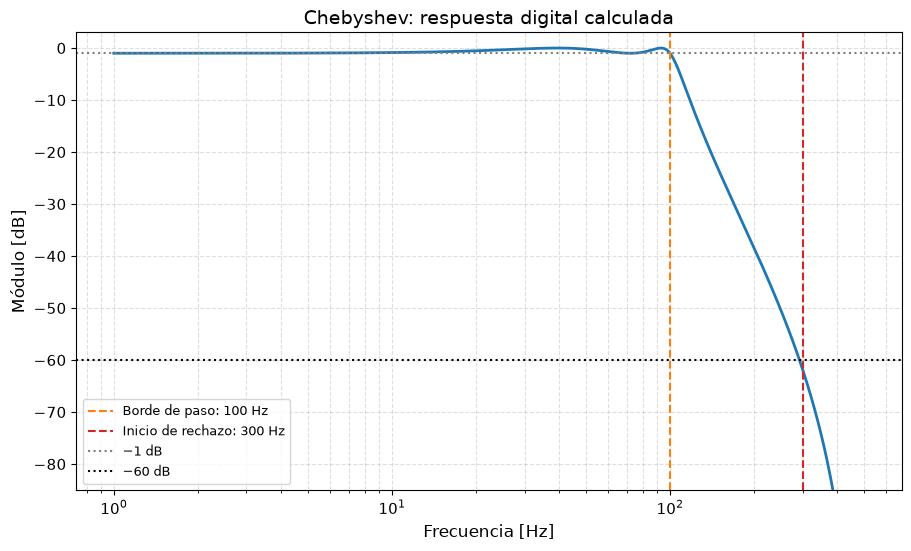

| Frecuencia [Hz] | Módulo calculado [dB] | Atenuación [dB] | Condición | Resultado |
| --- | --- | --- | --- | --- |
| 100 | -1,00 | 1,00 | A ≤ 1 dB | Cumple |
| 300 | -61,86 | 61,86 | A ≥ 60 dB | Cumple |


In [7]:
# ============================================================
# Chebyshev: respuesta y verificación de la plantilla
# ============================================================
f_teoria = np.geomspace(1, FS_SAMPLING / 2 * 0.998, 5000)
_, h_a = signal.sosfreqz(sos_a, worN=f_teoria, fs=FS_SAMPLING)

fig, ax = plt.subplots(figsize=(9, 5.4), layout="constrained")
ax.semilogx(f_teoria, (20 * np.log10(np.maximum(np.abs(h_a), 1e-15))), color="tab:blue", lw=2)
ax.axvline(A_WP, color="tab:orange", ls="--", label=f"Borde de paso: {A_WP:g} Hz")
ax.axvline(A_WS, color="tab:red", ls="--", label=f"Inicio de rechazo: {A_WS:g} Hz")
ax.axhline(-A_GPASS, color="gray", ls=":", label=f"−{A_GPASS:g} dB")
ax.axhline(-A_GSTOP, color="black", ls=":", label=f"−{A_GSTOP:g} dB")
ax.set(title="Chebyshev: respuesta digital calculada", ylim=(-85, 3),
       xlabel="Frecuencia [Hz]", ylabel="Módulo [dB]")
ax.grid(True, which="both", ls="--", alpha=0.4)
ax.legend(fontsize=9)
plt.show()
plt.close(fig)

_, h_limites = signal.sosfreqz(sos_a, worN=[A_WP, A_WS], fs=FS_SAMPLING)
m_limites = (20 * np.log10(np.maximum(np.abs(h_limites), 1e-15)))
a_limites = -m_limites
mostrar_tabla(
    ["Frecuencia [Hz]", "Módulo calculado [dB]", "Atenuación [dB]", "Condición", "Resultado"],
    [
        [f"{A_WP:g}", formato(m_limites[0]), formato(a_limites[0]),
         f"A ≤ {A_GPASS:g} dB", "Cumple" if a_limites[0] <= A_GPASS + 1e-9 else "No cumple"],
        [f"{A_WS:g}", formato(m_limites[1]), formato(a_limites[1]),
         f"A ≥ {A_GSTOP:g} dB", "Cumple" if a_limites[1] >= A_GSTOP - 1e-9 else "No cumple"],
    ]
)

### <ins>1.5.2 Notch: verificación del ancho de banda</ins>

En el notch se verifica la frecuencia del rechazo y el ancho de banda entre sus dos cruces de media potencia. La ganancia de referencia fuera del rechazo es unitaria, por lo que los cruces se determinan resolviendo

$$|H(f_1)|^2=|H(f_2)|^2=\frac{1}{2},\qquad f_1<f_0<f_2.$$

Este nivel corresponde a

$$20\log_{10}\left(\frac{1}{\sqrt{2}}\right)=-3{,}0103\,\mathrm{dB},$$

habitualmente denominado nivel de **−3 dB**. El ancho de banda calculado es

$$BW_{3\mathrm{dB}}=f_2-f_1,$$

y se compara con el valor solicitado de $1\,\mathrm{Hz}$.

Se utiliza `brentq` para encontrar un cruce a cada lado del notch. De esta manera, el cálculo del ancho de banda no depende del paso de la grilla utilizada para dibujar la curva. La posición de los cruces se obtiene de la transferencia digital, sin incluir las redes RC.

| Parámetro | Valor calculado |
| --- | --- |
| Frecuencia central de diseño | 50,0000 Hz |
| Nivel de media potencia | -3,0103 dB |
| Cruce inferior f1 | 49,502417 Hz |
| Cruce superior f2 | 50,502417 Hz |
| BW calculado = f2 − f1 | 1,000000 Hz |
| BW solicitado | 1,000000 Hz |
| Diferencia absoluta | 1.66e-12 Hz |
| Verificación numérica (tolerancia: 0,000001 Hz) | Cumple |


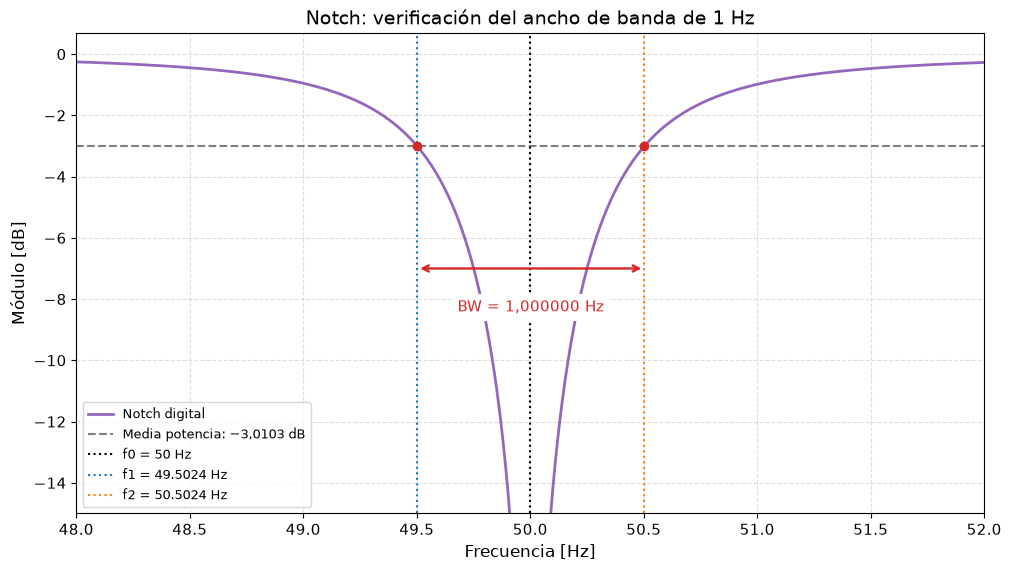

In [8]:
# ============================================================
# Notch: cruces de media potencia y ancho de banda
# ============================================================
NIVEL_3DB = 20 * np.log10(1 / np.sqrt(2))

def error_media_potencia(f):
    _, h = signal.sosfreqz(sos_b, worN=[f], fs=FS_SAMPLING)
    return np.abs(h[0])**2 - 0.5

f1_notch = brentq(error_media_potencia, 0, B_FNOTCH, xtol=1e-10)
f2_notch = brentq(error_media_potencia, B_FNOTCH, FS_SAMPLING / 2, xtol=1e-10)
bw_notch = f2_notch - f1_notch
error_bw = abs(bw_notch - B_BW3DB)
cumple_bw = np.isclose(bw_notch, B_BW3DB, rtol=0, atol=1e-6)

mostrar_tabla(
    ["Parámetro", "Valor calculado"],
    [
        ["Frecuencia central de diseño", f"{formato(B_FNOTCH, 4)} Hz"],
        ["Nivel de media potencia", f"{formato(NIVEL_3DB, 4)} dB"],
        ["Cruce inferior f1", f"{formato(f1_notch, 6)} Hz"],
        ["Cruce superior f2", f"{formato(f2_notch, 6)} Hz"],
        ["BW calculado = f2 − f1", f"{formato(bw_notch, 6)} Hz"],
        ["BW solicitado", f"{formato(B_BW3DB, 6)} Hz"],
        ["Diferencia absoluta", f"{error_bw:.2e} Hz"],
        ["Verificación numérica (tolerancia: 0,000001 Hz)", "Cumple" if cumple_bw else "No cumple"],
    ]
)

margen_notch = 2 * B_BW3DB
f_zoom = np.unique(np.r_[
    np.linspace(max(0, B_FNOTCH - margen_notch),
                min(FS_SAMPLING / 2, B_FNOTCH + margen_notch), 5001),
    B_FNOTCH, f1_notch, f2_notch
])
_, h_b_zoom = signal.sosfreqz(sos_b, worN=f_zoom, fs=FS_SAMPLING)

fig, ax = plt.subplots(figsize=(10, 5.6), layout="constrained")
ax.plot(f_zoom, (20 * np.log10(np.maximum(np.abs(h_b_zoom), 1e-15))), color="tab:purple", lw=2, label="Notch digital")
ax.axhline(NIVEL_3DB, color="gray", ls="--", label="Media potencia: −3,0103 dB")
ax.axvline(B_FNOTCH, color="black", ls=":", label=f"f0 = {B_FNOTCH:g} Hz")
ax.axvline(f1_notch, color="tab:blue", ls=":", label=f"f1 = {f1_notch:.4f} Hz")
ax.axvline(f2_notch, color="tab:orange", ls=":", label=f"f2 = {f2_notch:.4f} Hz")
ax.scatter([f1_notch, f2_notch], [NIVEL_3DB, NIVEL_3DB], color="tab:red", zorder=5)
ax.annotate("", xy=(f1_notch, -7), xytext=(f2_notch, -7),
            arrowprops={"arrowstyle": "<->", "color": "tab:red", "lw": 1.7})
ax.text((f1_notch + f2_notch) / 2, -8.4,
        f"BW = {bw_notch:.6f} Hz".replace(".", ","),
        ha="center", color="tab:red", bbox={"facecolor": "white", "edgecolor": "none"})
ax.set(title="Notch: verificación del ancho de banda de 1 Hz",
       xlabel="Frecuencia [Hz]", ylabel="Módulo [dB]", ylim=(-15, 0.7),
       xlim=(f_zoom.min(), f_zoom.max()))
ax.grid(True, ls="--", alpha=0.4)
ax.legend(fontsize=9, loc="lower left")
plt.show()
plt.close(fig)

Los cruces se encuentran aproximadamente en $49{,}502417\,\mathrm{Hz}$ y $50{,}502417\,\mathrm{Hz}$, de modo que

$$BW_{3\mathrm{dB}}=50{,}502417-49{,}502417=1{,}000000\,\mathrm{Hz}.$$

El diseño digital cumple el ancho de banda solicitado. Los cruces no son exactamente simétricos respecto de $50\,\mathrm{Hz}$; por eso se calculan ambos en lugar de suponer $f_1=49{,}5\,\mathrm{Hz}$ y $f_2=50{,}5\,\mathrm{Hz}$.

El nivel de media potencia es $-3{,}0103\,\mathrm{dB}$. Si se utilizara literalmente $-3{,}0000\,\mathrm{dB}$, el ancho de banda cambiaría ligeramente. Esta verificación corresponde al diseño en Python; para verificar el ancho de banda experimental todavía hacen falta mediciones próximas a ambos cruces.

## <ins>1.6 Carga de los coeficientes en la placa</ins>

Los coeficientes obtenidos en Python se cargaron en el código del microcontrolador para implementar el Chebyshev y el notch. En cada caso se configuró la cantidad de secciones correspondiente al filtro diseñado.

# <ins>2. Implementación experimental</ins>

El sistema se implementó con una placa NUCLEO-F446RE y dos filtros analógicos RC: uno de antialiasing antes del ADC y otro de interpolación después del DAC. Se utilizó un generador de señales para aplicar la entrada y un osciloscopio para medir las tensiones de entrada y salida.

## <ins>Instrumental utilizado</ins>

Los instrumentos utilizados se identifican mediante los códigos de inventario visibles en sus fotografías:

| Instrumento | Código de inventario |
|:--|:--|
| Osciloscopio digital | NG1387 |
| Generador de señales | NG1896 |

### <ins>Osciloscopio — NG1387</ins>

<div align="center">
    <img src="./Imagenes/Osciloscopio.jpeg" alt="Osciloscopio utilizado, inventario NG1387" width="500"/>
</div>

### <ins>Generador de señales — NG1896</ins>

<div align="center">
    <img src="./Imagenes/Generador.jpeg" alt="Generador de señales utilizado, inventario NG1896" width="400"/>
</div>

## <ins>Conexión del sistema de filtrado digital</ins>

La señal del generador se aplica al filtro de antialiasing y luego ingresa al ADC de la placa. El microcontrolador procesa las muestras y entrega la salida a través del DAC. Finalmente, la señal atraviesa el filtro de interpolación y se mide con el osciloscopio. Las conexiones comparten una referencia de masa.

El recorrido de la señal se muestra en el siguiente esquema:

<div align="center">
    <img src="./Imagenes/sistema_filtrado_digital.png" alt="Sistema de filtrado digital: generador, antialiasing, ADC, filtro digital, DAC, interpolación y osciloscopio" width="600"/>
</div>

## <ins>Montaje de los filtros de antialiasing e interpolación</ins>

Las dos etapas analógicas se montaron en una placa perforada. La imagen identifica la etapa de antialiasing, conectada entre el generador y la entrada del ADC, y la etapa de interpolación, conectada entre la salida del DAC y el osciloscopio. También se indica el punto común de masa.

<div align="center">
    <img src="./Imagenes/Filtro.png" alt="Filtros de antialiasing e interpolación y sus conexiones de entrada, salida y masa" width="500"/>
</div>

## <ins>2.1 Componentes y frecuencia de corte</ins>

Se armaron dos redes RC pasabajos de primer orden. La primera se coloca antes del ADC y atenúa las componentes de alta frecuencia que pueden generar aliasing. La segunda se coloca después del DAC y suaviza la señal reconstruida. Cada red utiliza

$$R=6{,}8\,\mathrm{k\Omega},\qquad C=91{,}6\,\mathrm{nF}.$$

La transferencia y la frecuencia de corte de cada etapa son

$$H_{\mathrm{RC}}(s)=\frac{1}{1+sRC},\qquad f_c=\frac{1}{2\pi RC}\approx255{,}5\,\mathrm{Hz}.$$

Cada RC cae a razón de $20\,\mathrm{dB/dec}$ a frecuencias altas. Su rechazo por encima de Nyquist es limitado; los $60\,\mathrm{dB}$ de la plantilla del Chebyshev corresponden al filtro digital.

In [9]:
# ============================================================
# Parámetros de las etapas RC
# ============================================================
R = 6.8e3
C = 91.6e-9
TAU_RC = R * C
FC_RC = 1 / (2 * np.pi * TAU_RC)
FC_CONJUNTO = FC_RC * np.sqrt(np.sqrt(2) - 1)

def h_rc(f):
    return 1 / (1 + 1j * 2 * np.pi * np.asarray(f) * TAU_RC)

def ganancia_dos_rc(f):
    # Modelo de dos etapas con efectos de carga despreciables.
    return (20 * np.log10(np.maximum(np.abs(h_rc(f)**2), 1e-15)))

print(f"Constante de tiempo de cada RC: {TAU_RC * 1e6:.2f} µs")
print(f"Corte de cada etapa: {FC_RC:.2f} Hz")
print(f"Corte de −3 dB de las dos etapas: {FC_CONJUNTO:.2f} Hz")

Constante de tiempo de cada RC: 622.88 µs
Corte de cada etapa: 255.51 Hz
Corte de −3 dB de las dos etapas: 164.45 Hz


## <ins>2.2 Por qué se obtienen aproximadamente −6 dB</ins>

A la frecuencia de corte de cada etapa, el módulo es $1/\sqrt{2}$ y la ganancia es aproximadamente $-3{,}01\,\mathrm{dB}$. Al atravesar ambas redes, los módulos se multiplican y las ganancias en dB se suman:

$$|H_{\mathrm{total}}(f_c)|=\frac{1}{\sqrt{2}}\frac{1}{\sqrt{2}}=\frac{1}{2},$$

$$G_{\mathrm{total}}(f_c)=20\log_{10}\left(\frac{1}{2}\right)\approx-6{,}02\,\mathrm{dB}.$$

Para dos etapas iguales, despreciando los efectos de carga,

$$|H_{\mathrm{total}}(f)|=\frac{1}{1+(f/f_c)^2}.$$

Por lo tanto, los $255{,}5\,\mathrm{Hz}$ identifican el corte de **cada RC**. El conjunto alcanza $-3\,\mathrm{dB}$ a una frecuencia menor, cercana a $164{,}4\,\mathrm{Hz}$.

## <ins>2.3 Configuración y medición en TALKTHROUGH</ins>

Para configurar y medir las etapas analógicas se utilizó el modo **TALKTHROUGH**. En esta configuración, el programa copia las muestras de entrada a la salida sin aplicar los coeficientes del filtro digital. La medición incluye las redes RC y el recorrido ADC–DAC.

Se utilizó una señal de entrada de **3,3 Vpp**, con un **offset de 1,65 V**, y se varió su frecuencia. La tabla siguiente transcribe las tensiones proporcionadas y recalcula la ganancia como

$$G_{\mathrm{dB}}=20\log_{10}\left(\frac{V_{\mathrm{out,pp}}}{V_{\mathrm{in,pp}}}\right).$$

Los valores negativos representan atenuación. En la primera tabla original, los dB estaban expresados como atenuación positiva; aquí se mantiene la misma convención de ganancia para todos los filtros.

In [10]:
# ============================================================
# Mediciones en TALKTHROUGH
# ============================================================
f_tt = np.array([10, 50, 100, 150, 200, 255, 300], dtype=float)
vin_tt = np.full(f_tt.shape, 3.3)
vout_tt = np.array([3.27, 3.07, 2.72, 2.31, 1.9, 1.63, 1.39])
g_tt = (20 * np.log10(np.maximum(np.abs(vout_tt / vin_tt), 1e-15)))

mostrar_tabla(
    ["Frecuencia [Hz]", "Vin [Vpp]", "Vout [Vpp]", "Vout/Vin", "Ganancia medida [dB]", "Modelo dos RC [dB]"],
    [[f"{f:g}", formato(vi), formato(vo), formato(vo / vi, 4), formato(g), formato(gt)]
     for f, vi, vo, g, gt in zip(f_tt, vin_tt, vout_tt, g_tt, ganancia_dos_rc(f_tt))]
)

| Frecuencia [Hz] | Vin [Vpp] | Vout [Vpp] | Vout/Vin | Ganancia medida [dB] | Modelo dos RC [dB] |
| --- | --- | --- | --- | --- | --- |
| 10 | 3,30 | 3,27 | 0,9909 | -0,08 | -0,01 |
| 50 | 3,30 | 3,07 | 0,9303 | -0,63 | -0,33 |
| 100 | 3,30 | 2,72 | 0,8242 | -1,68 | -1,24 |
| 150 | 3,30 | 2,31 | 0,7000 | -3,10 | -2,57 |
| 200 | 3,30 | 1,90 | 0,5758 | -4,80 | -4,15 |
| 255 | 3,30 | 1,63 | 0,4939 | -6,13 | -6,00 |
| 300 | 3,30 | 1,39 | 0,4212 | -7,51 | -7,53 |


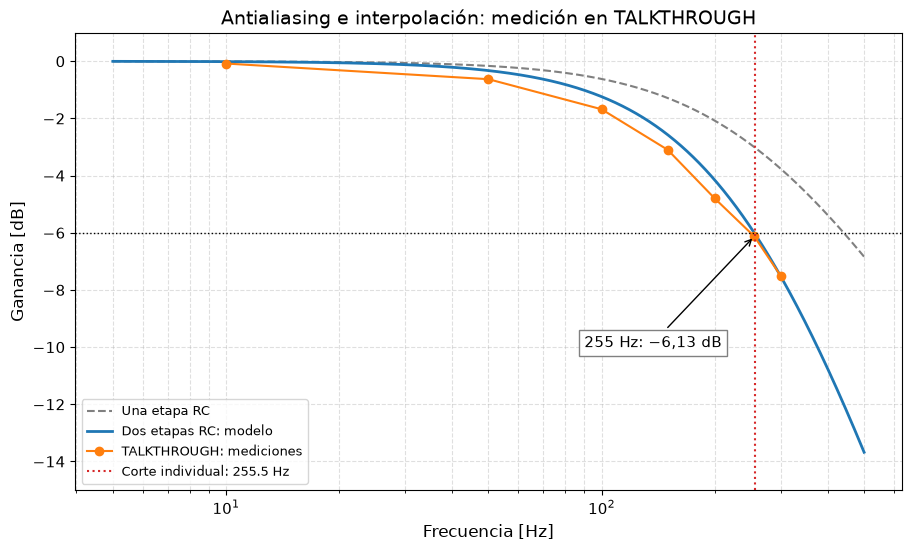

In [11]:
# ============================================================
# Comparación de TALKTHROUGH con el modelo RC
# ============================================================
f_rc = np.geomspace(5, 500, 2000)
fig, ax = plt.subplots(figsize=(9, 5.4), layout="constrained")
ax.semilogx(f_rc, (20 * np.log10(np.maximum(np.abs(h_rc(f_rc)), 1e-15))), "--", color="gray", label="Una etapa RC")
ax.semilogx(f_rc, ganancia_dos_rc(f_rc), color="tab:blue", lw=2, label="Dos etapas RC: modelo")
ax.semilogx(f_tt, g_tt, "o-", color="tab:orange", label="TALKTHROUGH: mediciones")
ax.axvline(FC_RC, color="tab:red", ls=":", label=f"Corte individual: {FC_RC:.1f} Hz")
ax.axhline(-6.0206, color="black", ls=":", lw=1)
ax.annotate("255 Hz: −6,13 dB", (255, g_tt[5]), xytext=(90, -10),
            arrowprops={"arrowstyle": "->"}, bbox={"facecolor": "white", "edgecolor": "gray"})
ax.set(title="Antialiasing e interpolación: medición en TALKTHROUGH", xlabel="Frecuencia [Hz]", ylabel="Ganancia [dB]", ylim=(-15, 1))
ax.grid(True, which="both", ls="--", alpha=0.4)
ax.legend(fontsize=9)
plt.show()
plt.close(fig)

## <ins>2.4 Análisis de la medición analógica</ins>

A $255\,\mathrm{Hz}$ se obtuvo una salida de $1{,}63\,\mathrm{Vpp}$ para una entrada de $3{,}3\,\mathrm{Vpp}$:

$$G(255\,\mathrm{Hz})=20\log_{10}\left(\frac{1{,}63}{3{,}3}\right)\approx-6{,}13\,\mathrm{dB}.$$

El resultado es cercano a los $-6{,}02\,\mathrm{dB}$ esperados en el corte individual de las redes. A $300\,\mathrm{Hz}$ también se observa una proximidad entre el modelo de dos RC y la medición. A frecuencias menores quedan diferencias entre ambos, por lo que no se atribuye toda la respuesta medida únicamente a las redes ideales.

# <ins>3. Mediciones del Chebyshev</ins>

## <ins>3.1 Condiciones y datos obtenidos</ins>

Se seleccionó el modo **IIR** con los coeficientes del Chebyshev. Se midieron las tensiones pico a pico de entrada y salida entre $5$ y $300\,\mathrm{Hz}$, manteniendo una entrada de $3{,}3\,\mathrm{Vpp}$. El barrido permite observar la variación de ganancia en la banda de paso y la caída hacia la banda de rechazo.

Los puntos se ordenan por frecuencia. La tabla proporcionada repite el punto de $50\,\mathrm{Hz}$ con los mismos valores; se representa una sola vez.

In [12]:
# ============================================================
# Datos medidos: Chebyshev
# ============================================================
f_cheby = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100, 150, 200, 250, 300], dtype=float)
vin_cheby = np.full(f_cheby.shape, 3.3)
vout_cheby = np.array([3, 3, 3.03, 3.07, 3.11, 3.16, 3.2, 3.16, 3.07, 3, 2.59, 2.48, 0.2, 0.016, 0.004, 0.004])
g_cheby = (20 * np.log10(np.maximum(np.abs(vout_cheby / vin_cheby), 1e-15)))

mostrar_tabla(
    ["Frecuencia [Hz]", "Vin [Vpp]", "Vout [Vpp]", "Vout/Vin", "Ganancia [dB]"],
    [[f"{f:g}", formato(vi), formato(vo, 3), formato(vo / vi, 5), formato(g)]
     for f, vi, vo, g in zip(f_cheby, vin_cheby, vout_cheby, g_cheby)]
)

| Frecuencia [Hz] | Vin [Vpp] | Vout [Vpp] | Vout/Vin | Ganancia [dB] |
| --- | --- | --- | --- | --- |
| 5 | 3,30 | 3,000 | 0,90909 | -0,83 |
| 10 | 3,30 | 3,000 | 0,90909 | -0,83 |
| 15 | 3,30 | 3,030 | 0,91818 | -0,74 |
| 20 | 3,30 | 3,070 | 0,93030 | -0,63 |
| 25 | 3,30 | 3,110 | 0,94242 | -0,52 |
| 30 | 3,30 | 3,160 | 0,95758 | -0,38 |
| 35 | 3,30 | 3,200 | 0,96970 | -0,27 |
| 40 | 3,30 | 3,160 | 0,95758 | -0,38 |
| 45 | 3,30 | 3,070 | 0,93030 | -0,63 |
| 50 | 3,30 | 3,000 | 0,90909 | -0,83 |
| 75 | 3,30 | 2,590 | 0,78485 | -2,10 |
| 100 | 3,30 | 2,480 | 0,75152 | -2,48 |
| 150 | 3,30 | 0,200 | 0,06061 | -24,35 |
| 200 | 3,30 | 0,016 | 0,00485 | -46,29 |
| 250 | 3,30 | 0,004 | 0,00121 | -58,33 |
| 300 | 3,30 | 0,004 | 0,00121 | -58,33 |


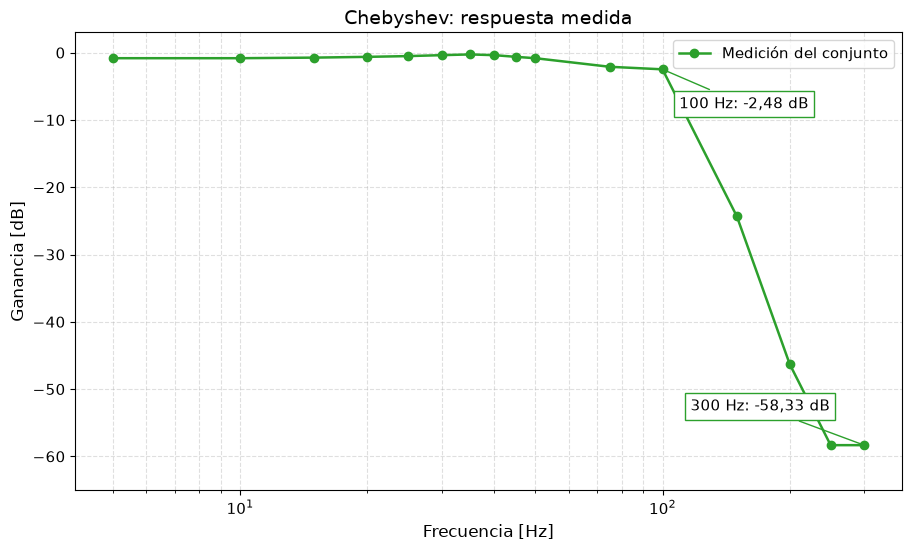

In [13]:
# ============================================================
# Respuesta experimental del Chebyshev
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.4), layout="constrained")
ax.semilogx(f_cheby, g_cheby, "o-", color="tab:green", lw=1.8, label="Medición del conjunto")
for f, desplazamiento in [(100, (12, -28)), (300, (-125, 25))]:
    g = g_cheby[np.flatnonzero(f_cheby == f)[0]]
    ax.annotate(f"{f} Hz: {g:.2f} dB".replace(".", ","), (f, g),
                xytext=desplazamiento, textcoords="offset points",
                bbox={"facecolor": "white", "edgecolor": "tab:green"},
                arrowprops={"arrowstyle": "-", "color": "tab:green"})
ax.set(title="Chebyshev: respuesta medida", xlabel="Frecuencia [Hz]", ylabel="Ganancia [dB]", ylim=(-65, 3))
ax.grid(True, which="both", ls="--", alpha=0.4)
ax.legend()
plt.show()
plt.close(fig)

## <ins>3.2 Análisis de los resultados</ins>

La salida disminuye considerablemente por encima de $100\,\mathrm{Hz}$, mostrando el comportamiento pasabajos. A $100\,\mathrm{Hz}$ se obtuvo una ganancia de $-2{,}48\,\mathrm{dB}$ y a $300\,\mathrm{Hz}$, de $-58{,}33\,\mathrm{dB}$. Estos valores corresponden al conjunto medido y contienen la influencia de las etapas analógicas.

La salida registrada a $250$ y $300\,\mathrm{Hz}$ fue la misma: $4\,\mathrm{mVpp}$. Con los datos disponibles no puede establecerse si representa solamente la señal residual o si está condicionada por el ruido y la resolución de la medición. Tampoco se dispone de incertidumbres instrumentales para cuantificar esas diferencias.

# <ins>4. Mediciones del notch</ins>

## <ins>4.1 Condiciones y datos obtenidos</ins>

Se seleccionó el modo **IIR** con los coeficientes del notch. Se midieron las tensiones pico a pico entre $10$ y $75\,\mathrm{Hz}$, manteniendo una entrada de $3{,}3\,\mathrm{Vpp}$. Se concentraron los puntos alrededor de $50\,\mathrm{Hz}$ para observar el rechazo y la recuperación de amplitud a ambos lados.

In [14]:
# ============================================================
# Datos medidos: notch
# ============================================================
f_notch = np.array([10, 25, 35, 45, 48, 50, 51, 55, 65, 75], dtype=float)
vin_notch = np.full(f_notch.shape, 3.3)
vout_notch = np.array([3.3, 3.27, 3.24, 3.2, 3.07, 0.1, 2.7, 3, 3, 2.9])
g_notch = (20 * np.log10(np.maximum(np.abs(vout_notch / vin_notch), 1e-15)))

mostrar_tabla(
    ["Frecuencia [Hz]", "Vin [Vpp]", "Vout [Vpp]", "Vout/Vin", "Ganancia [dB]"],
    [[f"{f:g}", formato(vi), formato(vo), formato(vo / vi, 5), formato(g)]
     for f, vi, vo, g in zip(f_notch, vin_notch, vout_notch, g_notch)]
)

| Frecuencia [Hz] | Vin [Vpp] | Vout [Vpp] | Vout/Vin | Ganancia [dB] |
| --- | --- | --- | --- | --- |
| 10 | 3,30 | 3,30 | 1,00000 | 0,00 |
| 25 | 3,30 | 3,27 | 0,99091 | -0,08 |
| 35 | 3,30 | 3,24 | 0,98182 | -0,16 |
| 45 | 3,30 | 3,20 | 0,96970 | -0,27 |
| 48 | 3,30 | 3,07 | 0,93030 | -0,63 |
| 50 | 3,30 | 0,10 | 0,03030 | -30,37 |
| 51 | 3,30 | 2,70 | 0,81818 | -1,74 |
| 55 | 3,30 | 3,00 | 0,90909 | -0,83 |
| 65 | 3,30 | 3,00 | 0,90909 | -0,83 |
| 75 | 3,30 | 2,90 | 0,87879 | -1,12 |


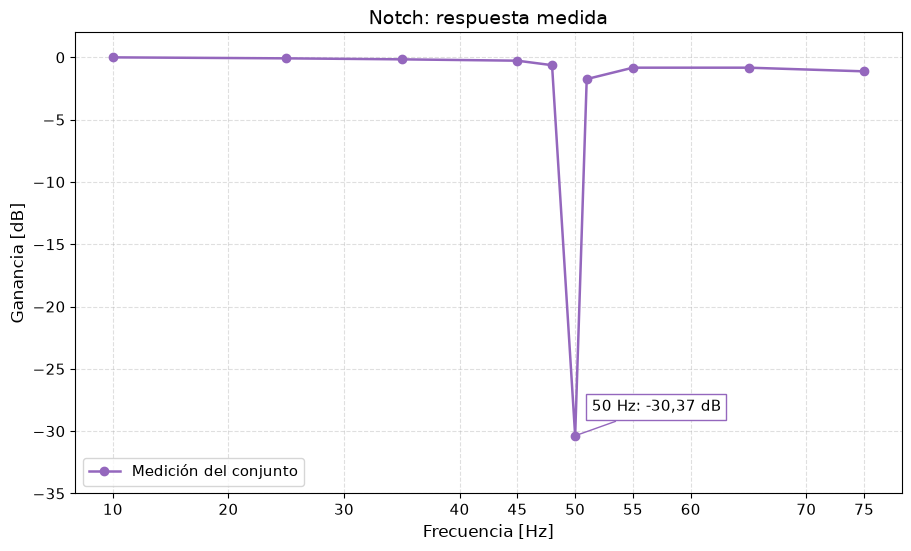

In [15]:
# ============================================================
# Respuesta experimental del notch
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.4), layout="constrained")
ax.plot(f_notch, g_notch, "o-", color="tab:purple", lw=1.8, label="Medición del conjunto")
g_50 = g_notch[np.flatnonzero(f_notch == 50)[0]]
ax.annotate(f"50 Hz: {g_50:.2f} dB".replace(".", ","), (50, g_50),
            xytext=(12, 18), textcoords="offset points",
            bbox={"facecolor": "white", "edgecolor": "tab:purple"},
            arrowprops={"arrowstyle": "-", "color": "tab:purple"})
ax.set(title="Notch: respuesta medida", xlabel="Frecuencia [Hz]", ylabel="Ganancia [dB]", ylim=(-35, 2))
ax.set_xticks([10, 20, 30, 40, 45, 50, 55, 60, 70, 75])
ax.grid(True, ls="--", alpha=0.4)
ax.legend()
plt.show()
plt.close(fig)

## <ins>4.2 Análisis de los resultados</ins>

El menor valor de salida registrado se obtuvo a $50\,\mathrm{Hz}$, con $0{,}10\,\mathrm{Vpp}$. La ganancia calculada es

$$G(50\,\mathrm{Hz})=20\log_{10}\left(\frac{0{,}10}{3{,}3}\right)\approx-30{,}37\,\mathrm{dB}.$$

Los puntos de la tabla de tensiones no permiten verificar el ancho de banda de $1\,\mathrm{Hz}$. La estimación gráfica a partir de la captura del analizador se presenta en el apartado 5.1. Para determinarlo deben identificarse ambos cruces de $-3\,\mathrm{dB}$ con un barrido más fino. Las líneas entre los puntos medidos son una guía visual y no constituyen una medición continua del filtro.

# <ins>5. Comparación con el analizador de audio</ins>

## <ins>5.1 Capturas del analizador</ins>

Se utilizó un analizador de audio Agilent Technologies U8903A para observar el módulo de la respuesta en función de la frecuencia. Las siguientes capturas muestran los resultados del Chebyshev y del notch. Se distinguen las lecturas numéricas de los marcadores de las observaciones que pueden hacerse sobre las curvas.

### <ins>Chebyshev pasabajos</ins>

<div align="center">
    <img src="./Imagenes/Analizador_cheby.png" alt="Respuesta del Chebyshev en el analizador de audio: marcador a 309,3 Hz y −51,3 dB" width="800"/>
</div>

La curva muestra la caída del módulo al aumentar la frecuencia. La lectura del **Marker 1**, ubicada en la parte superior de la pantalla, indica

$$f=309{,}3\,\mathrm{Hz},\qquad M=-51{,}3\,\mathrm{dB}.$$

En ese punto, el nivel medido presenta una atenuación de **51,3 dB respecto de la referencia del gráfico**. Esta lectura permite cuantificar la caída en una frecuencia próxima al inicio de la banda de rechazo.

A $100\,\mathrm{Hz}$ no se dispone de una lectura numérica del marcador, pero se observa que la curva se encuentra por encima de $-4\,\mathrm{dB}$. 

### <ins>Notch de 50 Hz</ins>

<div align="center">
    <img src="./Imagenes/Analizador_notch.png" alt="Respuesta del notch en el analizador de audio: marcador a 50 Hz y −27 dB" width="700"/>
</div>

La captura muestra un rechazo localizado alrededor de $50\,\mathrm{Hz}$. La lectura del **Marker 1** indica

$$f=50{,}0\,\mathrm{Hz},\qquad M=-27{,}0\,\mathrm{dB}.$$

El mínimo observado alcanza **$-27\,\mathrm{dB}$**, que es el valor registrado para caracterizar la profundidad del rechazo en esta medición. A ambos lados del notch, la curva recupera su nivel de paso.

Aunque la imagen no permite una lectura directa del ancho de banda con cursores, se puede realizar una **estimación gráfica** a partir de la escala horizontal. El barrido va de $45$ a $55\,\mathrm{Hz}$, con $50\,\mathrm{Hz}$ en el centro. Al dividir cada intervalo de $5\,\mathrm{Hz}$ en diez partes iguales se obtienen referencias de $0{,}5\,\mathrm{Hz}$.

Para estimar el ancho de banda se identifican los cruces de la curva con un nivel situado aproximadamente **$3\,\mathrm{dB}$ por debajo de la banda de paso**. La referencia es el nivel de paso observado, que no coincide exactamente con $0\,\mathrm{dB}$. Al proyectar esos cruces sobre la escala de frecuencia, sus posiciones pueden ubicarse aproximadamente en

$$f_1\approx49{,}5\,\mathrm{Hz},\qquad f_2\approx50{,}5\,\mathrm{Hz}.$$

Por lo tanto, la separación estimada es

$$BW_{3\mathrm{dB}}\approx f_2-f_1\approx50{,}5-49{,}5=1\,\mathrm{Hz}.$$

Esta lectura gráfica es compatible con el ancho de banda de $1\,\mathrm{Hz}$ obtenido en el diseño. Se presenta como un valor **aproximado**, ya que el espesor de la traza, la perspectiva de la fotografía y la ausencia de marcadores en ambos cruces limitan la precisión. La lectura directa del marcador en el centro sigue siendo $50\,\mathrm{Hz}$ y $-27\,\mathrm{dB}$.


## <ins>5.2 Comparación gráfica del diseño y las mediciones</ins>

La respuesta obtenida en Python corresponde al filtro digital. La medición incluye el sistema conectado durante el ensayo. Para mostrar la influencia de las redes analógicas se superponen la respuesta digital, el modelo del filtro digital junto con las dos redes RC y los puntos medidos.

El modelo conjunto considera etapas RC sin efectos de carga. No incorpora las características particulares de los conversores ni permite explicar por sí solo todas las diferencias experimentales.

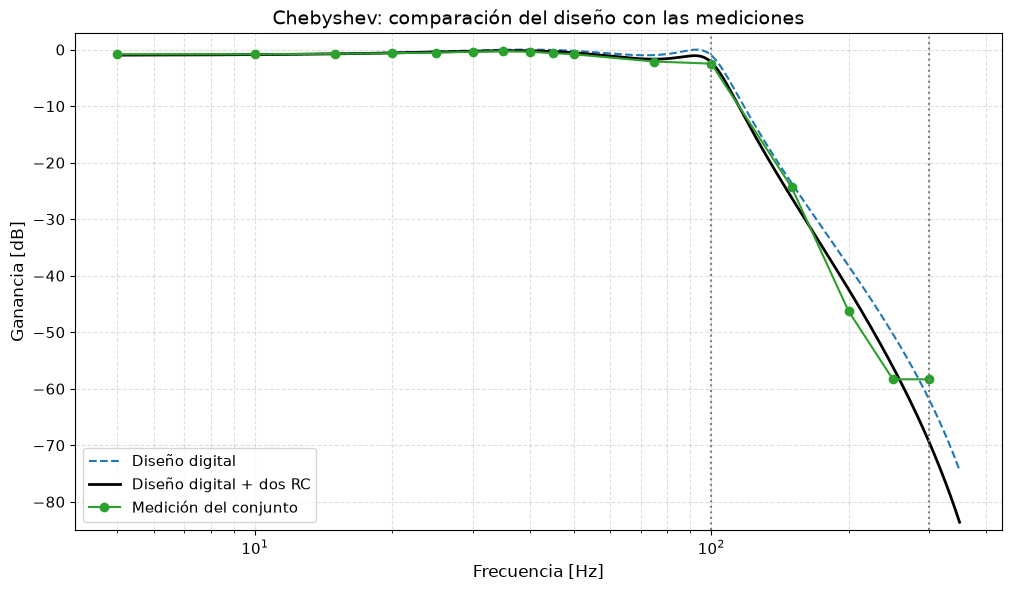

In [16]:
# ============================================================
# Comparación del Chebyshev
# ============================================================
f_comp = np.geomspace(5, 350, 5000)
_, h_cheby_comp = signal.sosfreqz(sos_a, worN=f_comp, fs=FS_SAMPLING)
fig, ax = plt.subplots(figsize=(10, 5.8), layout="constrained")
ax.semilogx(f_comp, (20 * np.log10(np.maximum(np.abs(h_cheby_comp), 1e-15))), "--", color="tab:blue", label="Diseño digital")
ax.semilogx(f_comp, (20 * np.log10(np.maximum(np.abs(h_cheby_comp * h_rc(f_comp)**2), 1e-15))), color="black", lw=2, label="Diseño digital + dos RC")
ax.semilogx(f_cheby, g_cheby, "o-", color="tab:green", label="Medición del conjunto")
ax.axvline(100, color="gray", ls=":")
ax.axvline(300, color="gray", ls=":")
ax.set(title="Chebyshev: comparación del diseño con las mediciones", xlabel="Frecuencia [Hz]", ylabel="Ganancia [dB]", ylim=(-85, 3))
ax.grid(True, which="both", ls="--", alpha=0.4)
ax.legend()
plt.show()
plt.close(fig)

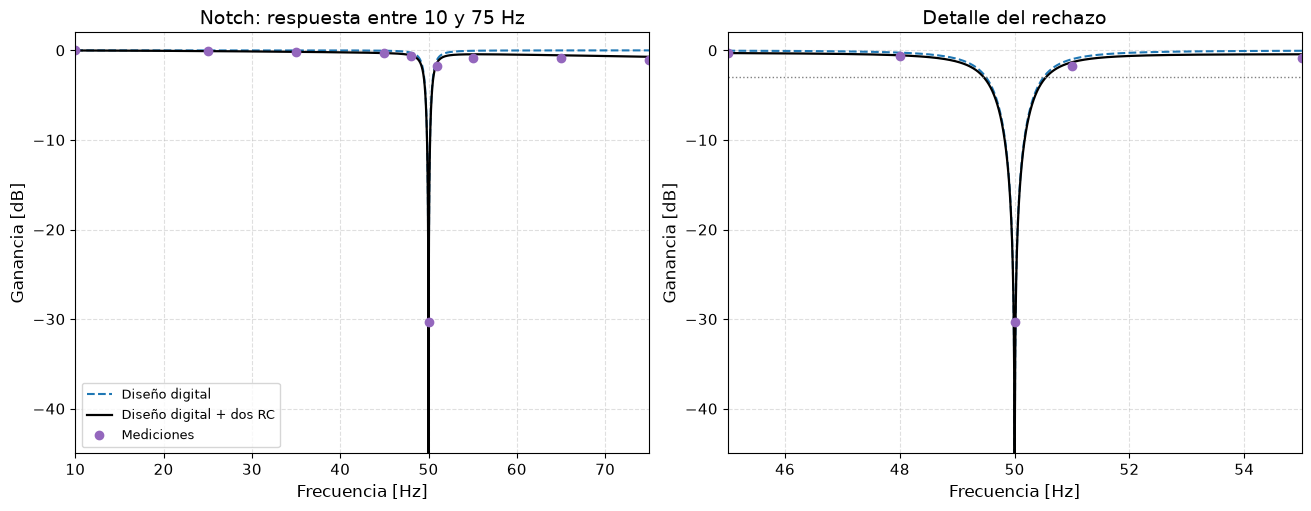

In [17]:
# ============================================================
# Comparación del notch: barrido amplio y detalle
# ============================================================
f_notch_comp = np.unique(np.r_[np.linspace(10, 75, 6000), np.linspace(49, 51, 4001)])
_, h_notch_comp = signal.sosfreqz(sos_b, worN=f_notch_comp, fs=FS_SAMPLING)
fig, ax = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for eje in ax:
    eje.plot(f_notch_comp, (20 * np.log10(np.maximum(np.abs(h_notch_comp), 1e-15))), "--", color="tab:blue", label="Diseño digital")
    eje.plot(f_notch_comp, (20 * np.log10(np.maximum(np.abs(h_notch_comp * h_rc(f_notch_comp)**2), 1e-15))), color="black", lw=1.6, label="Diseño digital + dos RC")
    eje.plot(f_notch, g_notch, "o", color="tab:purple", label="Mediciones")
    eje.set(xlabel="Frecuencia [Hz]", ylabel="Ganancia [dB]", ylim=(-45, 2))
    eje.grid(True, ls="--", alpha=0.4)
ax[0].set(title="Notch: respuesta entre 10 y 75 Hz", xlim=(10, 75))
ax[1].set(title="Detalle del rechazo", xlim=(45, 55))
ax[1].axhline(-3, color="gray", ls=":", lw=1)
ax[0].legend(fontsize=9)
plt.show()
plt.close(fig)

## <ins>5.3 Estimación de la contribución del filtro digital</ins>

Si las mediciones en TALKTHROUGH y en modo IIR se realizaron con las mismas conexiones y condiciones de adquisición y salida, puede estimarse la contribución digital mediante

$$G_{\mathrm{digital,est}}(f)=G_{\mathrm{IIR,med}}(f)-G_{\mathrm{TALKTHROUGH,med}}(f).$$

La tabla siguiente utiliza **solamente frecuencias medidas en ambas configuraciones**; no interpola ni reemplaza datos faltantes.

In [18]:
# ============================================================
# Corrección con la referencia TALKTHROUGH
# ============================================================
frecuencias_comunes = np.intersect1d(f_cheby, f_tt)
indices_cheby = np.searchsorted(f_cheby, frecuencias_comunes)
indices_tt = np.searchsorted(f_tt, frecuencias_comunes)
g_cheby_estimado = g_cheby[indices_cheby] - g_tt[indices_tt]
_, h_cheby_comunes = signal.sosfreqz(sos_a, worN=frecuencias_comunes, fs=FS_SAMPLING)

mostrar_tabla(
    ["Frecuencia [Hz]", "Conjunto IIR [dB]", "TALKTHROUGH [dB]", "Digital estimado [dB]", "Diseño digital [dB]"],
    [[f"{f:g}", formato(gm), formato(gr), formato(ge), formato(gt)]
     for f, gm, gr, ge, gt in zip(
         frecuencias_comunes, g_cheby[indices_cheby], g_tt[indices_tt],
         g_cheby_estimado, (20 * np.log10(np.maximum(np.abs(h_cheby_comunes), 1e-15))))]
)

| Frecuencia [Hz] | Conjunto IIR [dB] | TALKTHROUGH [dB] | Digital estimado [dB] | Diseño digital [dB] |
| --- | --- | --- | --- | --- |
| 10 | -0,83 | -0,08 | -0,75 | -0,87 |
| 50 | -0,83 | -0,63 | -0,20 | -0,22 |
| 100 | -2,48 | -1,68 | -0,80 | -1,00 |
| 150 | -24,35 | -3,10 | -21,25 | -23,61 |
| 200 | -46,29 | -4,80 | -41,49 | -38,27 |
| 300 | -58,33 | -7,51 | -50,82 | -61,86 |


## <ins>5.4 Análisis de las diferencias</ins>

El Chebyshev calculado presenta aproximadamente $-1\,\mathrm{dB}$ a $100\,\mathrm{Hz}$ y $-61{,}86\,\mathrm{dB}$ a $300\,\mathrm{Hz}$. En cambio, la medición del conjunto presenta $-2{,}48$ y $-58{,}33\,\mathrm{dB}$, respectivamente.

A $100\,\mathrm{Hz}$, la referencia TALKTHROUGH tiene una ganancia de $-1{,}68\,\mathrm{dB}$. Bajo la hipótesis de condiciones equivalentes, la contribución digital se estima como

$$G_{\mathrm{digital,est}}(100\,\mathrm{Hz})=-2{,}48-(-1{,}68)\approx-0{,}80\,\mathrm{dB}.$$

Este resultado es compatible con el límite de $1\,\mathrm{dB}$ **en ese punto**. No demuestra por sí solo el cumplimiento de toda la banda de paso; por ejemplo, no hay una referencia TALKTHROUGH medida a $75\,\mathrm{Hz}$.

A $300\,\mathrm{Hz}$, la misma corrección da aproximadamente $-50{,}82\,\mathrm{dB}$. Los datos disponibles no verifican el rechazo digital de $60\,\mathrm{dB}$. La repetición de una lectura de $4\,\mathrm{mVpp}$ requiere revisar el nivel residual y las condiciones de medición antes de atribuir la diferencia a una causa específica.

En el notch, el mínimo registrado a $50\,\mathrm{Hz}$ coincide con la frecuencia central de diseño. Su ganancia total medida es de $-30{,}37\,\mathrm{dB}$. La resolución del barrido alrededor del rechazo y el nivel residual deben considerarse al comparar su profundidad con el modelo ideal. Los puntos de la tabla de tensiones no alcanzan para determinar el ancho de banda. La captura del analizador permite una estimación gráfica de ambos cruces, próximos a $49{,}5$ y $50{,}5\,\mathrm{Hz}$, compatible con un ancho de banda de aproximadamente $1\,\mathrm{Hz}$. Una lectura más precisa requiere marcadores en los dos cruces.

Las capturas del analizador complementan las mediciones de amplitud: para el Chebyshev se registra un módulo de $-51{,}3\,\mathrm{dB}$ a $309{,}3\,\mathrm{Hz}$ y se observa que la curva a $100\,\mathrm{Hz}$ está por encima de $-4\,\mathrm{dB}$. Para el notch, el marcador indica $-27\,\mathrm{dB}$ a $50\,\mathrm{Hz}$, frente a los $-30{,}37\,\mathrm{dB}$ obtenidos en la tabla de tensiones. Se conservan ambos resultados como lecturas de mediciones diferentes. La fotografía del notch permite estimar un ancho de banda cercano a $1\,\mathrm{Hz}$ mediante la escala horizontal, aunque no ofrece una lectura precisa de los dos cruces de media potencia.

## <ins>Conclusión</ins>

El diseño en Python permitió obtener los coeficientes de un Chebyshev de cuarto orden y de un notch de segundo orden, y adaptarlos al formato utilizado por CMSIS-DSP. La medición en TALKTHROUGH mostró aproximadamente $-6\,\mathrm{dB}$ alrededor de $255\,\mathrm{Hz}$, consistente con la presencia de las dos etapas RC de entrada y salida.

Las mediciones con filtrado digital mostraron el comportamiento pasabajos del Chebyshev y el rechazo localizado del notch en $50\,\mathrm{Hz}$. La referencia TALKTHROUGH permite estimar la influencia analógica cuando se mantienen las condiciones de ensayo. Con ese criterio, el resultado del Chebyshev a $100\,\mathrm{Hz}$ es compatible con la plantilla en ese punto, mientras que el rechazo a $300\,\mathrm{Hz}$ y el ancho de banda del notch requieren una verificación experimental más precisa.

Las capturas del analizador de audio también muestran ambos comportamientos: el Chebyshev alcanza $-51{,}3\,\mathrm{dB}$ a $309{,}3\,\mathrm{Hz}$ y el notch presenta un mínimo de $-27\,\mathrm{dB}$ a $50\,\mathrm{Hz}$. A $100\,\mathrm{Hz}$, la curva del Chebyshev se observa por encima de $-4\,\mathrm{dB}$, sin una lectura exacta del marcador. La estimación gráfica de los cruces del notch, alrededor de $49{,}5$ y $50{,}5\,\mathrm{Hz}$, da un ancho de banda aproximado de $1\,\mathrm{Hz}$, compatible con el diseño y limitado por la resolución de la captura.
